# Регуляризация линейной регрессии: предсказание цен на дома

**Автор:** Лутченко Екатерина  
**Дата:** 06.10.2026
**Стек:** Python, pandas, scikit-learn, matplotlib, seaborn  

---

## О проекте

Практическая работа по построению и сравнению моделей линейной регрессии
с L1 (Lasso) и L2 (Ridge) регуляризацией на датасете Ames Housing.

**Задача:** предсказать цену продажи дома (`SalePrice`) на основе 26 признаков.

## Данные

Датасет содержит **1460 записей** о продажах домов. Признаки включают
характеристики дома (площадь, качество, год постройки, тип крыши),
условия продажи и целевую переменную `SalePrice`.

## Что было сделано

1. **EDA** — анализ распределений, корреляций, поиск мультиколлинеарности
2. **Feature engineering** — создано 5 новых признаков:
   - `YearHouseOld`, `YearsAfterRem` — возраст дома и давность ремонта
   - `Qual_x_Area` — произведение качества и площади (сильнейший признак)
   - `IsNew`, `WasRemodeled` — бинарные флаги
3. **Препроцессинг** — `ColumnTransformer` + `Pipeline`:
   - One-Hot для категориальных (с `handle_unknown='ignore'`)
   - Ordinal для порядковых признаков качества
   - StandardScaler для числовых
4. **Модели** — LinearRegression, Ridge, Lasso
   - Подбор `alpha` через `GridSearchCV` (5-fold CV)
5. **Оценка** — MAE, MSE, R² на train и test
6. **Диагностика** — графики остатков и предсказаний

## Результаты

| Модель | alpha | Test R² | Test MAE |
|---|---|---|---|
| LinearRegression | — | 0.8384 | 21 496 |
| Ridge | 356.22 | 0.8202 | 21 325 |
| **Lasso** | **1082.64** | **0.8389** | **20 883** |

**Ключевой вывод:** Lasso обнулил 69% признаков (34 из 49),
но показал лучшее качество на тесте и меньшую ошибку.

Краткое описание признаков:

* **LotArea** — размер участка в квадратных футах.
* **LotArea_M** — размер участка в квадратных метрах.
* **Street** — тип доступа к дороге.
* **BldgType** — тип жилья.
* **OverallQual** — общее качество материала и отделки.
* **OverallCond** — общая оценка состояния.
* **YearBuilt** — первоначальная дата постройки.
* **YearRemodAdd** — дата реконструкции.
* **RoofStyle** — тип крыши.
* **ExterQual** — качество материалов снаружи.
* **ExterCond** — текущее состояние материалов снаружи.
* **Foundation** — тип фундамента.
* **TotalBsmtSF** — общая площадь подвала в квадратных футах.
* **TotalBsmtSF_M** — общая площадь подвала в квадратных метрах.
* **Heating** — тип отопления.
* **HeatingQC** — качество и состояние отопления.
* **CentralAir** — кондиционирование.
* **GrLivArea** — жилая площадь в квадратных футах.
* **GrLivArea_M** — жилая площадь в квадратных метрах.
* **Bath** — количество ванных комнат.
* **KitchenQual** — качество кухни.
* **GarageArea** — площадь гаража в квадратных футах.
* **GarageArea_M** — площадь гаража в квадратных метрах.
* **DateSold** — месяц и год продажи.
* **SaleCondition** — условия сделки.
* **SalePrice** — стоимость продажи в долларах. Это целевая переменная, которую нам нужно предсказать.


## Задание 1

Подключите необходимые библиотеки.

In [1]:
### Ваш код здесь ###
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Задание 2

Считайте данные и посмотрите на несколько строк.

In [2]:
### Ваш код здесь ###
df = pd.read_csv('/content/data.csv')
print(df.head(5))

   LotArea   LotArea_M Street BldgType  OverallQual  OverallCond  YearBuilt  \
0     8450   785.03035   Pave     1Fam            7            5       2003   
1     9600   891.86880   Pave     1Fam            6            8       1976   
2    11250  1045.15875   Pave     1Fam            7            5       2001   
3     9550   887.22365   Pave     1Fam            7            5       1915   
4    14260  1324.79678   Pave     1Fam            8            5       2000   

   YearRemodAdd RoofStyle ExterQual  ... CentralAir GrLivArea  GrLivArea_M  \
0          2003     Gable        Gd  ...          Y      1710   158.864130   
1          1976     Gable        TA  ...          Y      1262   117.243586   
2          2002     Gable        Gd  ...          Y      1786   165.924758   
3          1970     Gable        TA  ...          Y      1717   159.514451   
4          2000     Gable        Gd  ...          Y      2198   204.200794   

   Bath KitchenQual GarageArea GarageArea_M  DateSold  S

## Задание 3

Разведочный анализ:

1. Вывод статистики для  признаков.

In [3]:
### Ваш код здесь ###
print(df.describe())

             LotArea     LotArea_M  OverallQual  OverallCond    YearBuilt  \
count    1460.000000   1460.000000  1460.000000  1460.000000  1460.000000   
mean    10516.828082    977.044879     6.099315     5.575342  1971.267808   
std      9981.264932    927.289456     1.382997     1.112799    30.202904   
min      1300.000000    120.773900     1.000000     1.000000  1872.000000   
25%      7553.500000    701.742811     5.000000     5.000000  1954.000000   
50%      9478.500000    880.581085     6.000000     5.000000  1973.000000   
75%     11601.500000   1077.814155     7.000000     6.000000  2000.000000   
max    215245.000000  19996.906235    10.000000     9.000000  2010.000000   

       YearRemodAdd  TotalBsmtSF  TotalBsmtSF_M    GrLivArea  GrLivArea_M  \
count   1460.000000  1460.000000    1460.000000  1460.000000  1460.000000   
mean    1984.865753  1057.429452      98.238368  1515.463699   140.791124   
std       20.645407   438.705324      40.757041   525.480383    48.818704  

In [4]:
print(df.isnull().sum())

LotArea          0
LotArea_M        0
Street           0
BldgType         0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
ExterQual        0
ExterCond        0
Foundation       0
TotalBsmtSF      0
TotalBsmtSF_M    0
Heating          0
HeatingQC        0
CentralAir       0
GrLivArea        0
GrLivArea_M      0
Bath             0
KitchenQual      0
GarageArea       0
GarageArea_M     0
DateSold         0
SaleCondition    0
SalePrice        0
dtype: int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LotArea        1460 non-null   int64  
 1   LotArea_M      1460 non-null   float64
 2   Street         1460 non-null   object 
 3   BldgType       1460 non-null   object 
 4   OverallQual    1460 non-null   int64  
 5   OverallCond    1460 non-null   int64  
 6   YearBuilt      1460 non-null   int64  
 7   YearRemodAdd   1460 non-null   int64  
 8   RoofStyle      1460 non-null   object 
 9   ExterQual      1460 non-null   object 
 10  ExterCond      1460 non-null   object 
 11  Foundation     1460 non-null   object 
 12  TotalBsmtSF    1460 non-null   int64  
 13  TotalBsmtSF_M  1460 non-null   float64
 14  Heating        1460 non-null   object 
 15  HeatingQC      1460 non-null   object 
 16  CentralAir     1460 non-null   object 
 17  GrLivArea      1460 non-null   int64  
 18  GrLivAre

2. Матрица корреляций числовых признаков. Удаление линейно-зависимых признаков из данных.

In [6]:
### Ваш код здесь ###
corr = df.corr(numeric_only=True)

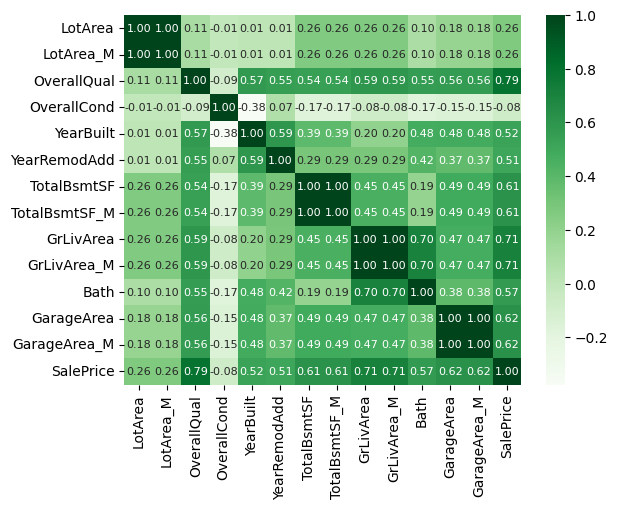

In [7]:
sns.heatmap(corr, annot = True, fmt='.2f', cmap='Greens',annot_kws={'fontsize': 8})
plt.show()

размер участка в футах/размер участка в метрах и другие аналогичные признаки полностью корелируют между собой

признаки с корелляцией = 1 будут удалены

In [8]:
# Удаляем дубликаты _M
df_clean = df.drop(columns=[
    'LotArea_M',
    'TotalBsmtSF_M',
    'GrLivArea_M',
    'GarageArea_M'
])

In [9]:
# Зависимость оставшихся числовых признаков с целевлй переменноц
corr_2 = df_clean.corr(numeric_only=True)
corr_top = corr_2['SalePrice'].abs().sort_values(ascending=False)
print(corr_top)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
Bath            0.568267
YearBuilt       0.522897
YearRemodAdd    0.507101
LotArea         0.263843
OverallCond     0.077856
Name: SalePrice, dtype: float64


3. Индивидуальные графики зависимости целевой функции и отдельной переменной.

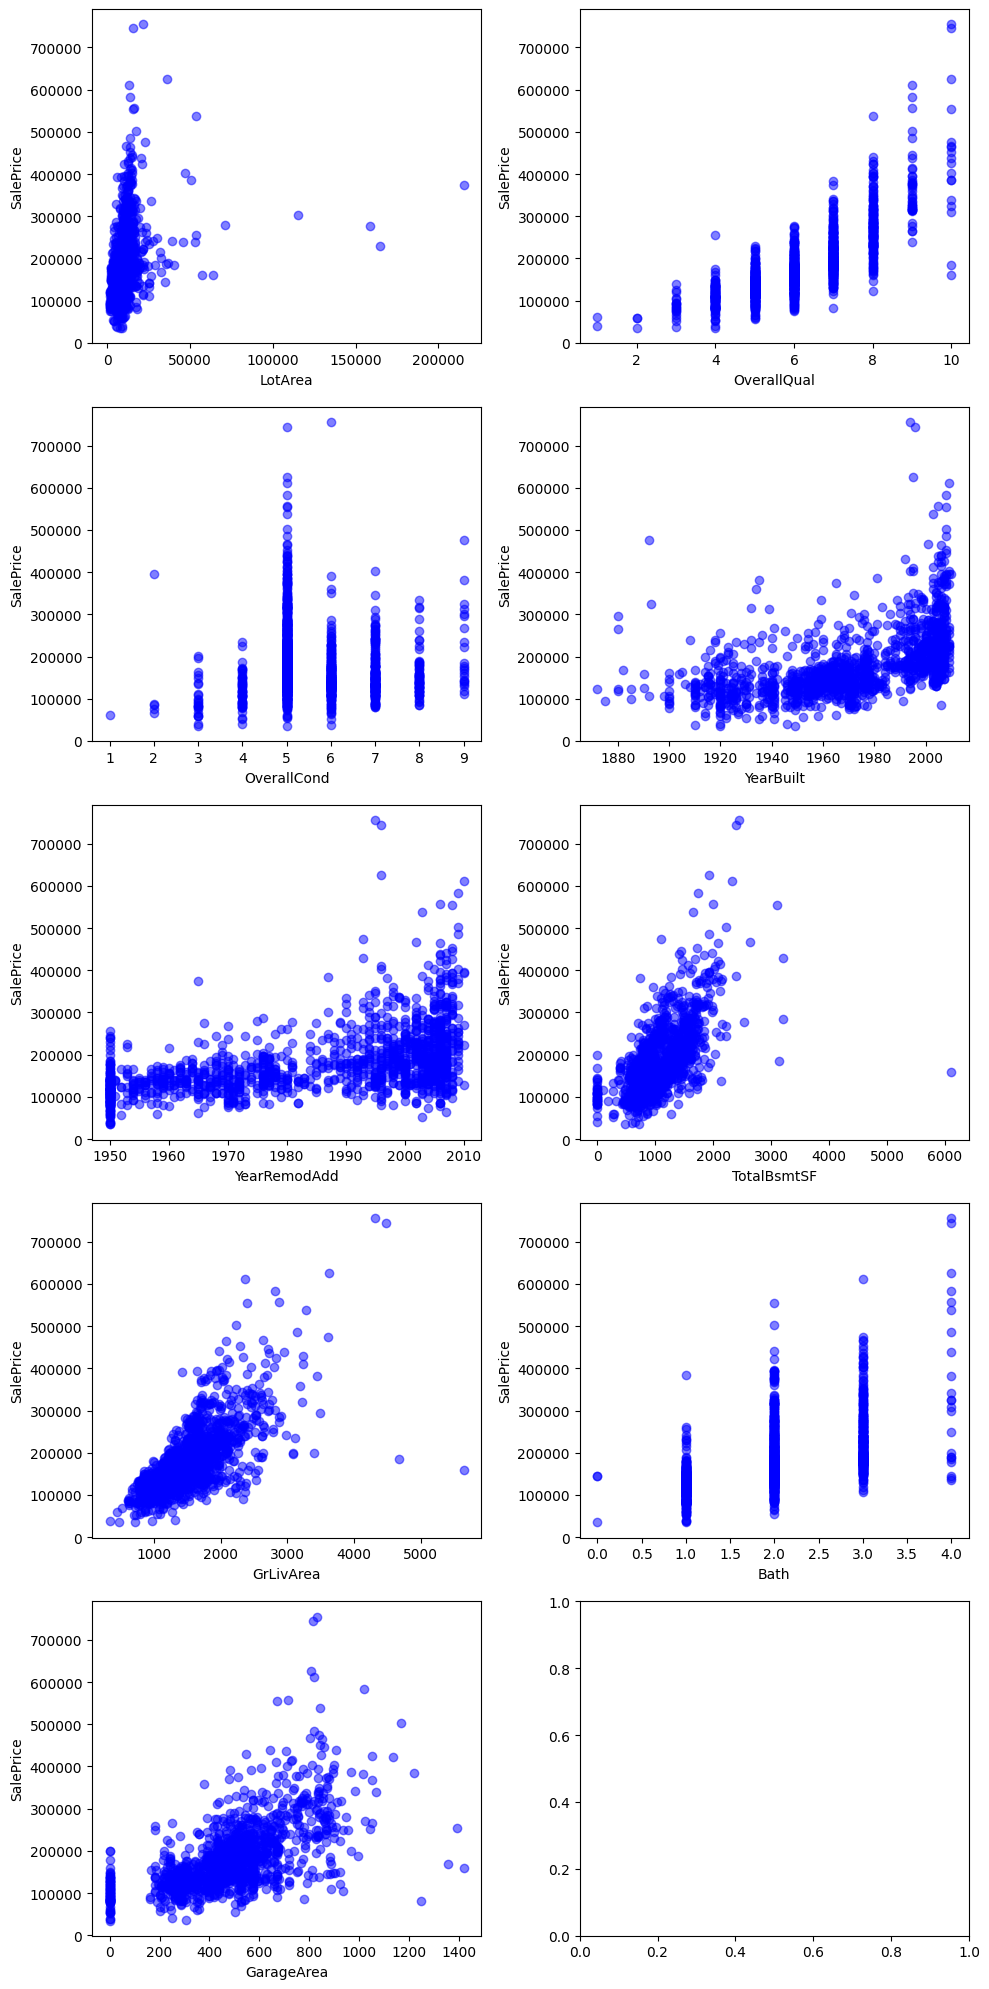

In [10]:
num_cols = [col for col in df_clean.select_dtypes(include='number').columns if col != 'SalePrice']

fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for col, ax in zip(num_cols, ax.flatten()):
    ax.scatter(df_clean[col], df_clean['SalePrice'], alpha=0.5, c='b')
    ax.set_xlabel(col)
    ax.set_ylabel('SalePrice')
plt.tight_layout()
plt.show()

In [11]:
num_cols

['LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'TotalBsmtSF',
 'GrLivArea',
 'Bath',
 'GarageArea']

 Распределение целевой переменной

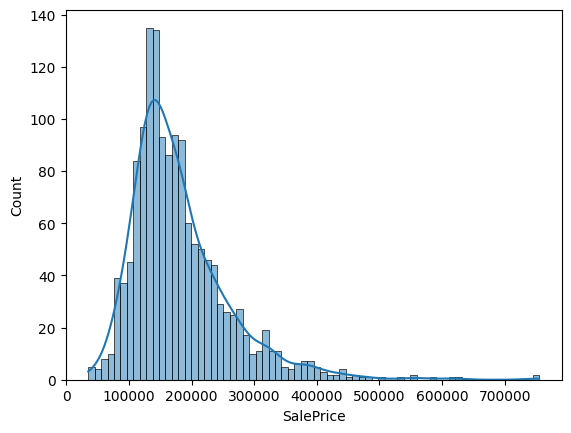

In [12]:
sns.histplot(df_clean['SalePrice'], bins=70, kde=True)
plt.show()

4. Предварительные выводы.

Целевая переменная рас пределена со скосом вправо, пик значений приходитсся на 120-140к

**Skewness (коэффициент асимметрии)** показывает, насколько
распределение «перекошено» относительно среднего.

- **Положительный skewness** (> 0) — длинный хвост справа.
  Типичный пример: доходы, цены на недвижимость.
- **Отрицательный skewness** (< 0) — длинный хвост слева.
  Пример: оценки на экзамене, где большинство получили максимум.
- **Skewness ≈ 0** — распределение симметрично (близко к нормальному).

Чем больше значение по модулю, тем сильнее асимметрия.

In [13]:
skew = stats.skew(df['SalePrice'])
print(f"Skewness: {skew:.3f}")

Skewness: 1.881


Также скос можно определить по среднему значению и медиане. Медиана устойчива к выбросам, она всегда в середине, а вот среднее значение тянется к длинному хвосту, соотвественно уходит вверх.

 mean > median ---> Правый скос (хвост справа)


In [14]:
target = df_clean.SalePrice
target.describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


5. Дополнительные переменные из уже имеющихся

Возраст дома а момент продажи

In [15]:
df_clean['YearSold'] = df_clean['DateSold'].str[-4:].astype(int)
df_clean['YearHouseOld'] = df_clean['YearSold'] - df_clean['YearBuilt']

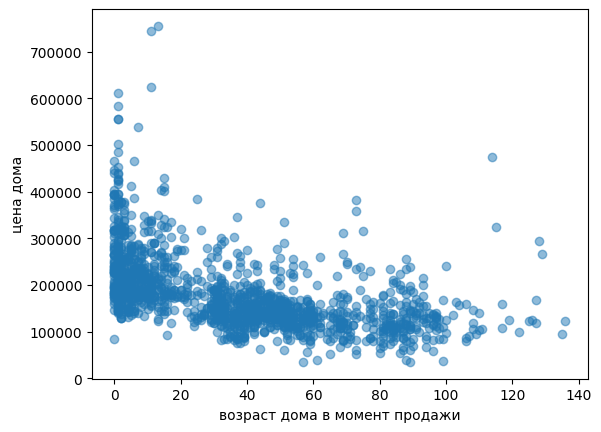

In [16]:
plt.scatter(df_clean['YearHouseOld'],  df_clean['SalePrice'], alpha=0.5)
plt.xlabel('возраст дома в момент продажи')
plt.ylabel('цена дома')
plt.show()

Количество лет между реставрацией и продажей

In [17]:
df_clean['YearsAfterRem'] = df_clean['YearSold'] - df_clean['YearRemodAdd']

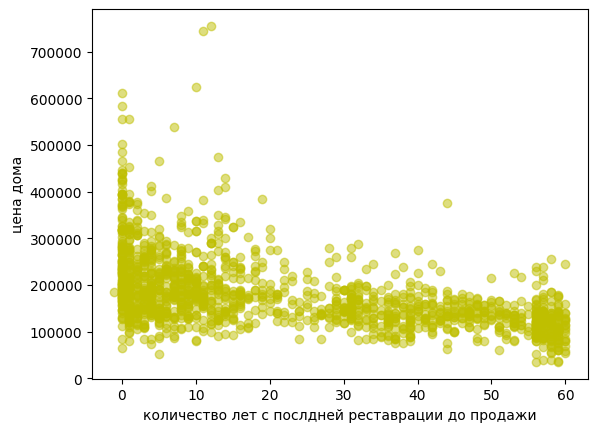

In [18]:
plt.scatter(df_clean['YearsAfterRem'], df_clean['SalePrice'], alpha=0.5, c='y')
plt.xlabel('количество лет с послдней реставрации до продажи')
plt.ylabel('цена дома')
plt.show()

«качество × площадь» топ 2 признака по кореляции с таргетом

In [19]:
df_clean['Qual_x_Area'] = df_clean['OverallQual'] * df_clean['GrLivArea']

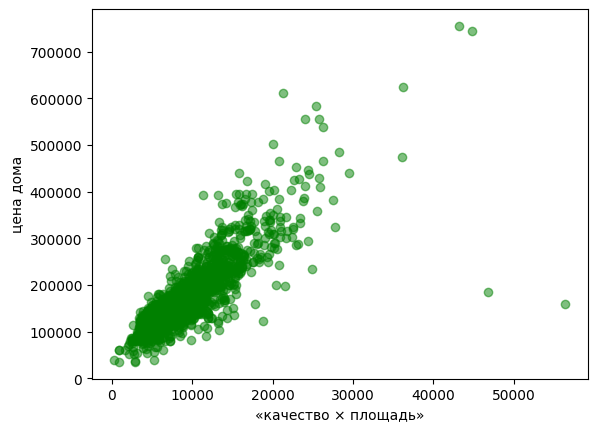

In [20]:
plt.scatter(df_clean['Qual_x_Area'], df_clean['SalePrice'], alpha=0.5, c='g')
plt.xlabel('«качество × площадь»')
plt.ylabel('цена дома')
plt.show()

Флаг для новых домов

In [21]:
df_clean['IsNew'] = (df_clean['YearHouseOld'] < 5).astype(int)

Посмотрим на кореляцию новых признаков с таргетом

In [24]:
corr_3 = df_clean[['IsNew','Qual_x_Area', 'YearsAfterRem', 'YearHouseOld', 'SalePrice']].corr()
new_features_corelation = corr_3['SalePrice'].abs().sort_values(ascending=False)
print(new_features_corelation)

SalePrice        1.000000
Qual_x_Area      0.832057
YearHouseOld     0.523350
YearsAfterRem    0.509079
IsNew            0.414711
Name: SalePrice, dtype: float64


## Задание 4

Подготовка данныx:

1. Разделение данных на тренировочную и тестовую выборки.

2. Кодировка категориальных признаков и стандартизация признаков числовых.

In [25]:
x = df_clean.drop(columns='SalePrice')
y = df_clean['SalePrice']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [26]:
print(df_clean.select_dtypes(object).nunique())

Street            2
BldgType          5
RoofStyle         6
ExterQual         4
ExterCond         5
Foundation        6
Heating           6
HeatingQC         5
CentralAir        2
KitchenQual       4
DateSold         55
SaleCondition     6
dtype: int64


удаляем из выборок DateSold, так как полезная информация из этого признака уже извлечена

In [27]:
x_train = x_train.drop(columns='DateSold')
x_test = x_test.drop(columns='DateSold')

пайплайн для обработки данных

In [28]:
binary_cols = ['Street', 'CentralAir'] # бинарные / 2 значения
ordinal_cols = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual'] # порядковые
nominal_cols = ['BldgType', 'RoofStyle', 'Foundation', 'Heating', 'SaleCondition'] # номинальные
numeric_cols = [
    'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
    'TotalBsmtSF', 'GrLivArea', 'Bath', 'GarageArea', 'YearSold',
    'YearHouseOld', 'YearsAfterRem', 'Qual_x_Area', 'IsNew'
] # числовые

In [29]:
preprocessor = ColumnTransformer (
    transformers = [
        ('binary', OneHotEncoder(drop='if_binary', sparse_output=False), binary_cols),
        ('ordinal', OrdinalEncoder(categories = [['Po', 'Fa', 'TA', 'Gd', 'Ex']]*4), ordinal_cols),
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('numeric', StandardScaler(), numeric_cols)
    ]
)

## Задание 5

Обучение моделей:

1. Обучение модели линейной регрессии без регуляризации. Посмотрим на веса полученной модели. Сделаем предсказания по обучающей и тестовой выборкам.

In [30]:
def show(name, model):
  y_tr = model.predict(x_train)
  y_te = model.predict(x_test)

  print(name)
  print(f"Train: MAE={mean_absolute_error(y_train, y_tr):>8.0f} "
    f"MSE={mean_squared_error(y_train, y_tr):>12.0f} "
    f"R2={r2_score(y_train, y_tr):.4f}")

  print(f"Test:  MAE={mean_absolute_error(y_test,  y_te):>8.0f} "
    f"MSE={mean_squared_error(y_test,  y_te):>12.0f} "
    f"R2={r2_score(y_test,  y_te):.4f}")

In [31]:
pipe_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
pipe_lr.fit(x_train, y_train)
show('LinearRegression', pipe_lr)

LinearRegression
Train: MAE=   20538 MSE=  1251612830 R2=0.7920
Test:  MAE=   21496 MSE=  1127820275 R2=0.8384


2. L1-регуляризация (Lasso). Найден лучший параметр регуляризации. Предсказания по обучающей и тестовой выборкам, замерено качество с помощью MAE, MSE, $R^2$. Для воспроизводимости результатов задан параметр `random_state=42` при определении модели Lasso.

In [32]:
pipe_lasso = Pipeline([('prep', preprocessor), ('model', Lasso(random_state=42))])
grid_lasso = GridSearchCV(pipe_lasso, {'model__alpha': np.logspace(-3, 4, 30)}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lasso.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('binary',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       sparse_output=False),
                                                                         ['Street',
                                                                          'CentralAir']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex'],
                                                                                                    ['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex'],
                                                                                                    ['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex'],
                                                                                                    ['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex']]),
                                                                         ['ExterQual',
                                                                          'ExterCond',
                                                                          'Heati...
       8.53167852e-02, 1.48735211e-01, 2.59294380e-01, 4.52035366e-01,
       7.88046282e-01, 1.37382380e+00, 2.39502662e+00, 4.17531894e+00,
       7.27895384e+00, 1.26896100e+01, 2.21221629e+01, 3.85662042e+01,
       6.72335754e+01, 1.17210230e+02, 2.04335972e+02, 3.56224789e+02,
       6.21016942e+02, 1.08263673e+03, 1.88739182e+03, 3.29034456e+03,
       5.73615251e+03, 1.00000000e+04])},
             scoring='neg_mean_squared_error')

In [33]:
print(f"Лучший результат alpha для Lasso {grid_lasso.best_params_['model__alpha']:.4f}")
best_lasso = grid_lasso.best_estimator_
show('Lasso', best_lasso)

Лучший результат alpha для Lasso 1082.6367
Lasso
Train: MAE=   20906 MSE=  1316168399 R2=0.7813
Test:  MAE=   20883 MSE=  1124139032 R2=0.8389


In [49]:
feature_names = best_lasso.named_steps['prep'].get_feature_names_out()
weights_lasso = best_lasso.named_steps['model'].coef_

n_total = len(weights_lasso)
n_zero  = (weights_lasso == 0).sum()

weights_df = pd.DataFrame({
    'feature': feature_names,
    'weight': weights_lasso
})

# Только ненулевые, отсортированные по |весу|
survivors = weights_df[weights_df['weight'] != 0].sort_values('weight', key=abs, ascending=False)
print("Признаки, которые модель оставила:")
print(survivors.to_string(index=False))

print(f"Всего признаков после препроцессинга: {n_total}")
print(f"Обнулено: {n_zero} ({n_zero/n_total*100:.1f}%)")
print(f"Осталось ненулевых: {n_total - n_zero}")

Признаки, которые модель оставила:
                 feature       weight
    numeric__Qual_x_Area 28870.895855
    numeric__OverallQual 12662.942976
    ordinal__KitchenQual 10681.470206
      numeric__YearBuilt  9274.394270
  nominal__BldgType_1Fam  7898.600295
     numeric__GarageArea  7824.001644
      ordinal__ExterQual  7745.560658
        numeric__LotArea  6462.340082
    numeric__TotalBsmtSF  5033.652729
nominal__RoofStyle_Gable -4679.759812
      numeric__GrLivArea  2980.913553
    numeric__OverallCond  2268.214927
   numeric__YearRemodAdd  1439.595578
      ordinal__HeatingQC   876.114492
           numeric__Bath   227.083982
Всего признаков после препроцессинга: 49
Обнулено: 34 (69.4%)
Осталось ненулевых: 15


3. L2-регуляризациея (Ridge). Найден лучший параметр регуляризации. Сделаны предсказания по обучающей и тестовой выборкам, замено качество с помощью MAE, MSE, $R^2$. Для воспроизводимости результатов задан параметр `random_state=42` при определении модели Ridge.

In [48]:
pipe_ridge = Pipeline([('prep', preprocessor), ('model', Ridge(random_state=42))])
grid_ridge = GridSearchCV(pipe_ridge, {'model__alpha': np.logspace(-3, 4, 30)}, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_ridge.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('binary',
                                                                         OneHotEncoder(drop='if_binary',
                                                                                       sparse_output=False),
                                                                         ['Street',
                                                                          'CentralAir']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex'],
                                                                                                    ['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex'],
                                                                                                    ['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex'],
                                                                                                    ['Po',
                                                                                                     'Fa',
                                                                                                     'TA',
                                                                                                     'Gd',
                                                                                                     'Ex']]),
                                                                         ['ExterQual',
                                                                          'ExterCond',
                                                                          'Heati...
       8.53167852e-02, 1.48735211e-01, 2.59294380e-01, 4.52035366e-01,
       7.88046282e-01, 1.37382380e+00, 2.39502662e+00, 4.17531894e+00,
       7.27895384e+00, 1.26896100e+01, 2.21221629e+01, 3.85662042e+01,
       6.72335754e+01, 1.17210230e+02, 2.04335972e+02, 3.56224789e+02,
       6.21016942e+02, 1.08263673e+03, 1.88739182e+03, 3.29034456e+03,
       5.73615251e+03, 1.00000000e+04])},
             scoring='neg_mean_squared_error')

In [46]:
print(f"Лучший результат для alpha для Ridge: {grid_ridge.best_params_['model__alpha']:.4f}")
best_ridge = grid_ridge.best_estimator_
print(show('Ridge', best_ridge))

Лучший результат для alpha для Ridge: 356.2248
Ridge
Train: MAE=   21235 MSE=  1349952607 R2=0.7757
Test:  MAE=   21325 MSE=  1254639383 R2=0.8202
None


In [44]:
ridge_coef_ = best_ridge.named_steps['model'].coef_
ridge_feature_names = best_ridge.named_steps['prep'].get_feature_names_out()
weights_ridge_df = pd.DataFrame({
    'feature': ridge_feature_names,
    'weight': ridge_coef_
})
print(weights_ridge_df.sort_values(by='weight', ascending=False))

                           feature        weight
47            numeric__Qual_x_Area  13800.486596
36            numeric__OverallQual  12995.658528
41              numeric__GrLivArea  10495.453461
43             numeric__GarageArea   7966.492687
5             ordinal__KitchenQual   7588.359710
40            numeric__TotalBsmtSF   7497.488587
2               ordinal__ExterQual   6395.529444
35                numeric__LotArea   6093.242641
6           nominal__BldgType_1Fam   4554.396259
38              numeric__YearBuilt   3901.826726
42                   numeric__Bath   3711.566622
14          nominal__RoofStyle_Hip   3269.577732
37            numeric__OverallCond   2870.638308
34  nominal__SaleCondition_Partial   2359.504510
4               ordinal__HeatingQC   2220.977674
19       nominal__Foundation_PConc   1903.249257
39           numeric__YearRemodAdd   1833.765833
48                  numeric__IsNew   1096.458120
1             binary__CentralAir_Y    913.330085
44               num

### Вывод по Ridge

Ridge с alpha=356 не улучшил предсказание по сравнению с LinearRegression
(Test R² = 0.8202 против 0.8384, Test MAE = 21 325 против 21 496).

Причина: в данной задаче изначально не было переобучения —
Test R² у LinearRegression (0.8384) оказался даже выше Train R² (0.7920).
Это означает, что модель хорошо обобщала, и регуляризация была не нужна
для борьбы с переобучением.

Ridge в данной задаче не дал улучшения. Это показывает, что
регуляризация полезна не всегда, а только когда есть проблема
(переобучение или мультиколлинеарность, мешающая модели). Lasso
справился лучше за счёт отбора признаков.

## Оценка результатов регрессии

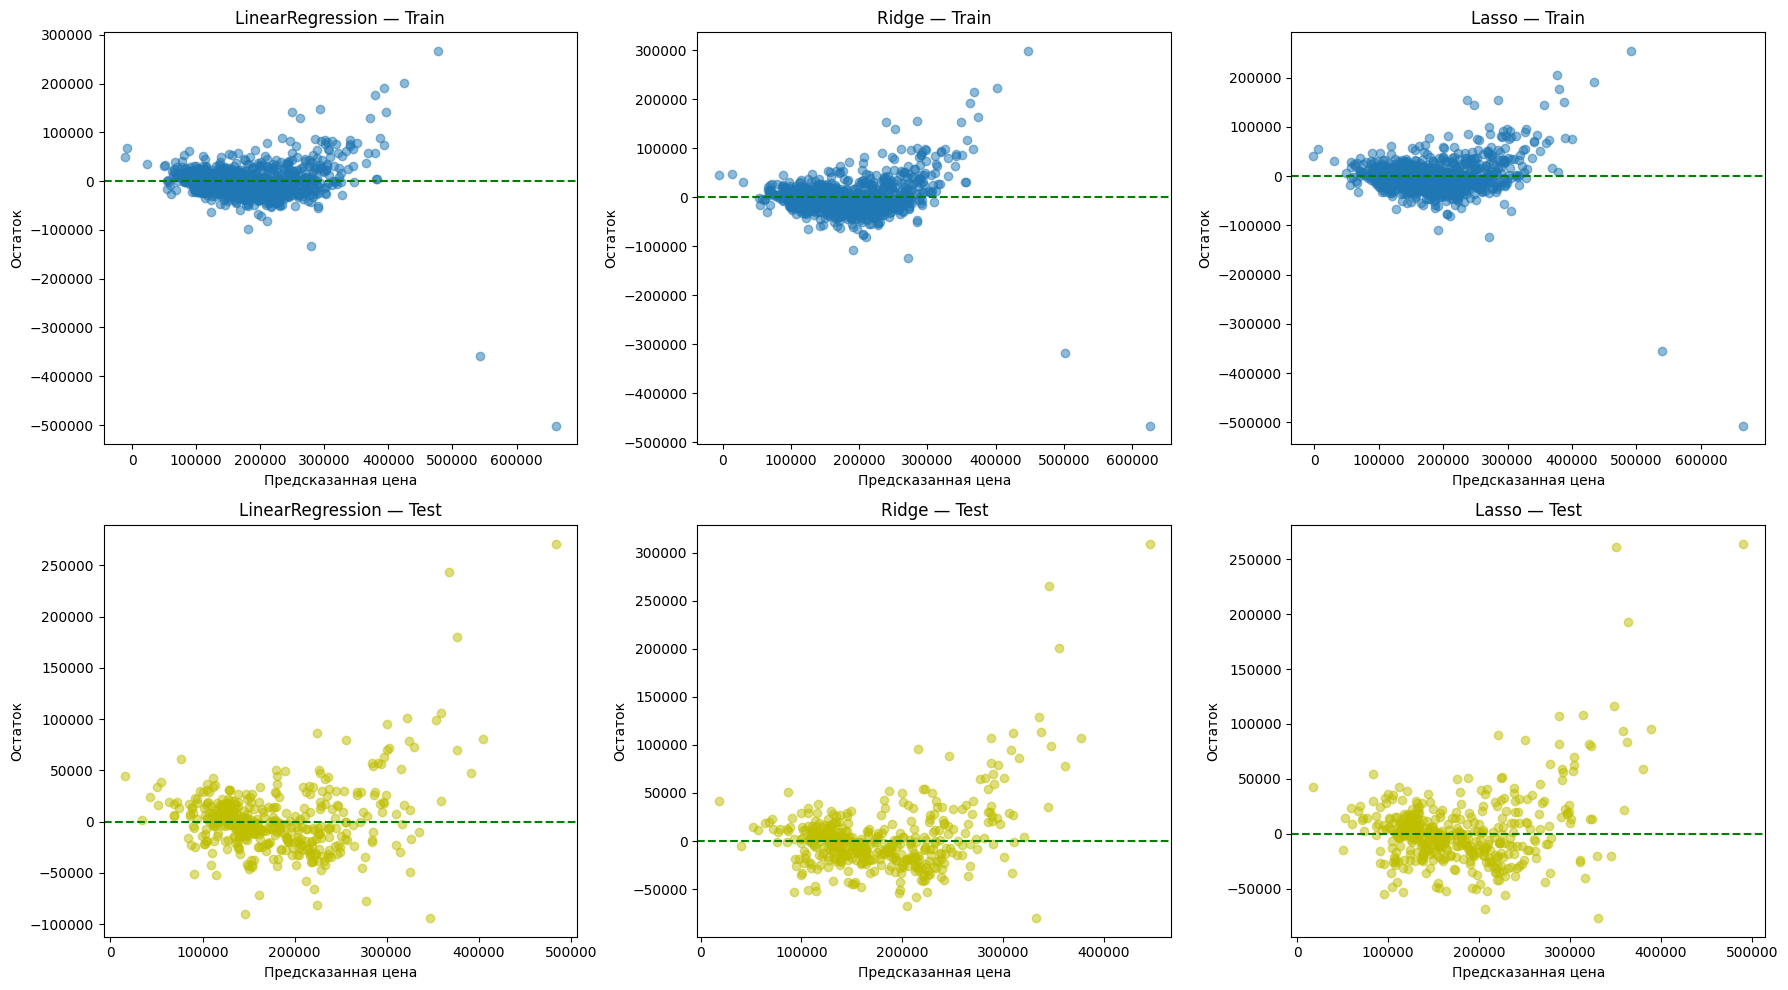

In [73]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models = [
    ('LinearRegression', pipe_lr),
    ('Ridge', best_ridge),
    ('Lasso', best_lasso),
]

for i, (name, model) in enumerate(models):
    # Train
    y_pred_tr = model.predict(x_train)
    res_tr = y_train - y_pred_tr
    axes[0, i].scatter(y_pred_tr, res_tr, alpha=0.5)
    axes[0, i].axhline(0, c='g', linestyle='--')
    axes[0, i].set_xlabel('Предсказанная цена')
    axes[0, i].set_ylabel('Остаток')
    axes[0, i].set_title(f'{name} — Train')

    # Test
    y_pred_te = model.predict(x_test)
    res_te = y_test - y_pred_te
    axes[1, i].scatter(y_pred_te, res_te, alpha=0.5, c='y')
    axes[1, i].axhline(0, c='g', linestyle='--')
    axes[1, i].set_xlabel('Предсказанная цена')
    axes[1, i].set_ylabel('Остаток')
    axes[1, i].set_title(f'{name} — Test')

plt.tight_layout()
plt.show()

На графиках остатков видны три ключевых наблюдения:

Гетероскедастичность - разброс остатков растёт с увеличением предсказанной цены. Для домов до 250k остатки в диапазоне ±50k, для домов дороже 400k - до ±200k. Это означает, что модель точнее предсказывает дешёвые дома и хуже - дорогие.
Выбросы - есть два дома на train с остатками −350k и −490k (модель сильно переоценила их цену) и один дом на test с остатком +260k (недооценила). Скорее всего, это дома с уникальными характеристиками, которые модель не видит.
Остатки скошены вправо - модель чаще недооценивает, чем переоценивает. Это следствие правого скоса SalePrice (skew = 1.88).
Все три модели дают одинаковую картину остатков — разница между ними минимальна. Это ожидаемо: все три — линейные модели, обучаются на одних данных и дают близкие предсказания.

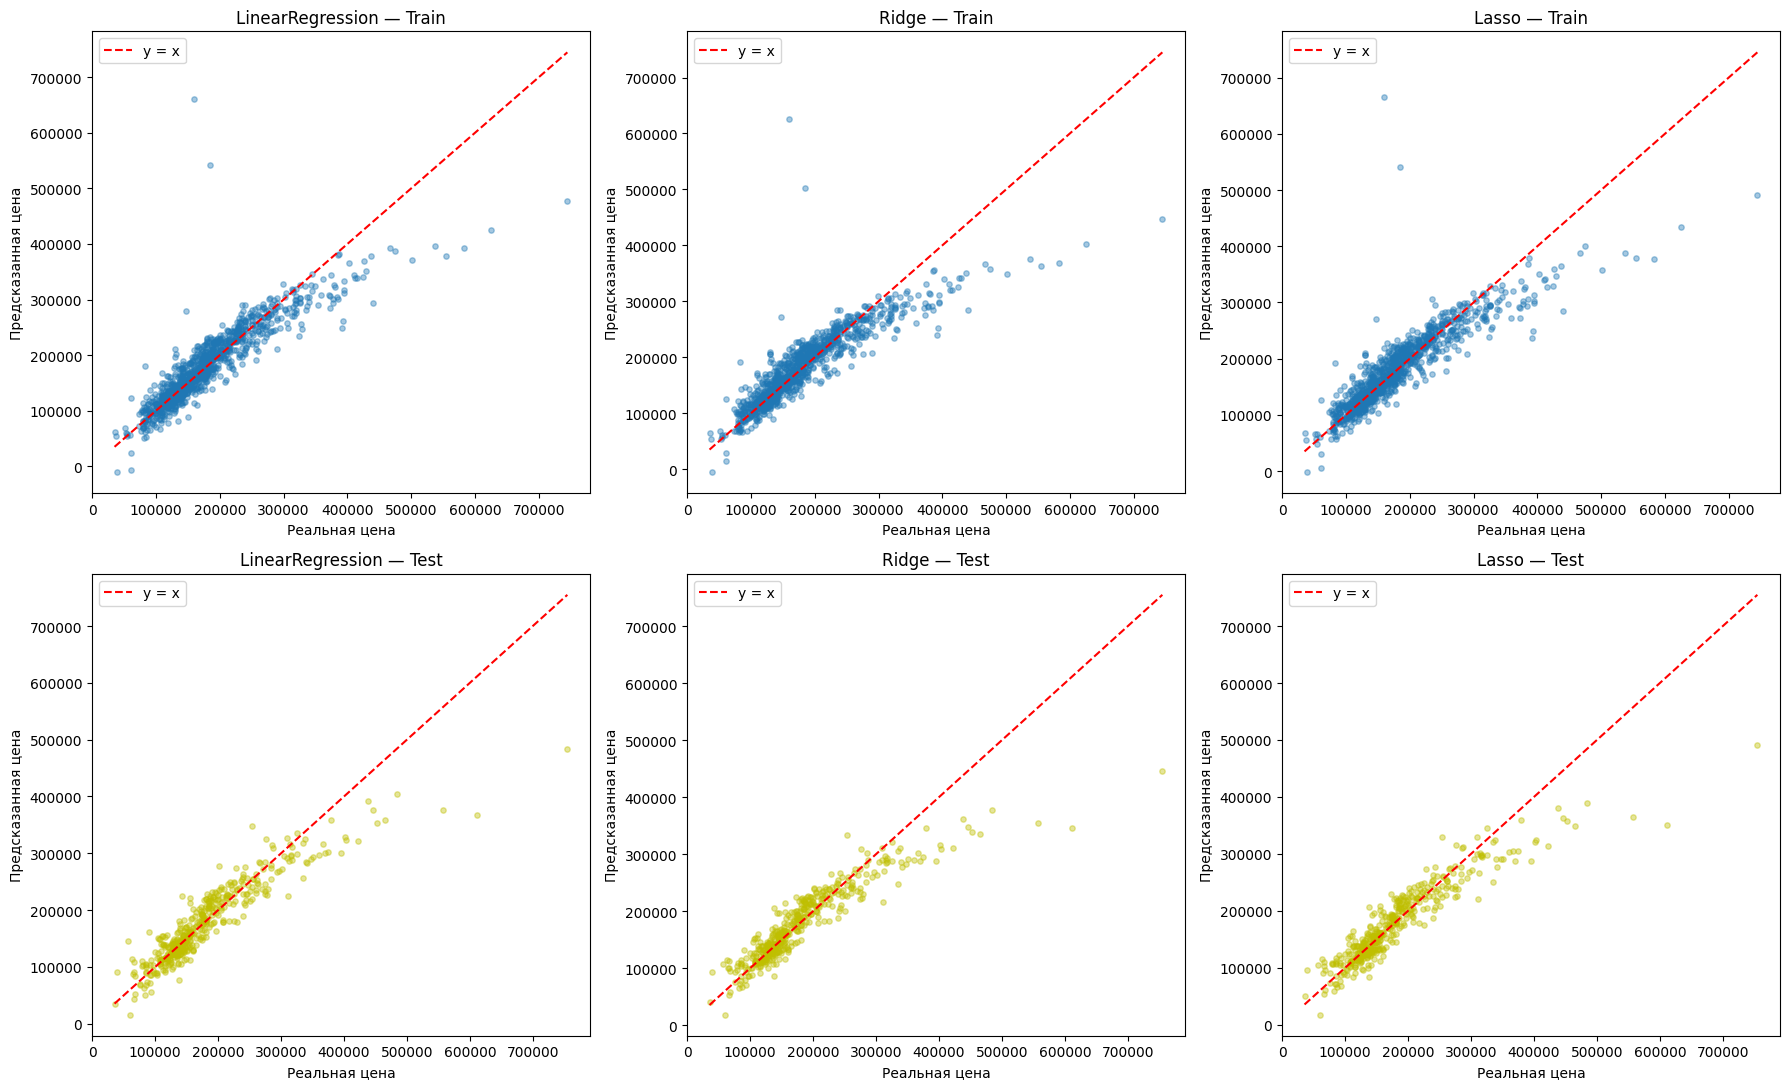

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

models = [
    ('LinearRegression', pipe_lr),
    ('Ridge', best_ridge),
    ('Lasso', best_lasso),
]

for i, (name, model) in enumerate(models):
    # Train
    y_pred_tr = model.predict(x_train)
    y_min, y_max = y_train.min(), y_train.max()
    axes[0, i].plot([y_min, y_max], [y_min, y_max],
                    'r--', linewidth=1.5, label='y = x')
    axes[0, i].scatter(y_train, y_pred_tr, alpha=0.4, s=15)
    axes[0, i].set_xlabel('Реальная цена')
    axes[0, i].set_ylabel('Предсказанная цена')
    axes[0, i].set_title(f'{name} — Train')
    axes[0, i].legend()

    # Test
    y_pred_te = model.predict(x_test)
    y_min, y_max = y_test.min(), y_test.max()
    axes[1, i].plot([y_min, y_max], [y_min, y_max],
                    'r--', linewidth=1.5, label='y = x')
    axes[1, i].scatter(y_test, y_pred_te, alpha=0.4, s=15, c='y')
    axes[1, i].set_xlabel('Реальная цена')
    axes[1, i].set_ylabel('Предсказанная цена')
    axes[1, i].set_title(f'{name} — Test')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

### Общий вывод

Графики остатков и "реальные vs предсказанные" показывают одинаковую картину для всех трёх моделей:

Модели хорошо предсказывают дешёвые и средние дома (100k–250k).
Хуже — дорогие дома (400k+), систематически их недооценивая.
Разброс ошибок растёт с ценой (гетероскедастичность).
Различия между LinearRegression, Ridge и Lasso не видны на графиках, потому что:

Переобучения в исходной модели не было (Test R² > Train R²).
Все три — линейные модели с одинаковой структурой.
Разница в Test R² — меньше 0.02.
Значит, регуляризация в этой задаче нужна не для улучшения предсказаний, а для:

Интерпретации (Lasso обнулил 69% признаков → понятно, какие признаки действительно более важны).
Стабильности весов (Ridge убирает проблему мультиколлинеарности).
Борьбы с переобучением на будущих данных (если появятся новые наблюдения, регуляризация защитит от переобучения).

Возможные улучшения модели:

Логарифмировать SalePrice — уменьшит скос и гетероскедастичность.
